# Working with Objects

Cells change shape depending on what they are doing. MuSpan has a number of tools to work with the shape of the cells in our data. MuSpan also has tools to work with points which may represent cell centers.

## Shapes into points - Shapes to centroids

Points are less computational to work with than shapes. MuSpan can create centroids from the shape of our cells.

Lets load some data and look at it's segmentation map.

In [2]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np

MuSpAn domain loaded successfully. Domain summary:
Domain name: Xenium-Healthy-Colon
Number of objects: 74174
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript', 'Transcript ID'] 
Networks: [] 
Distance matrices: []


(<Figure size 800x500 with 2 Axes>, <Axes: >)

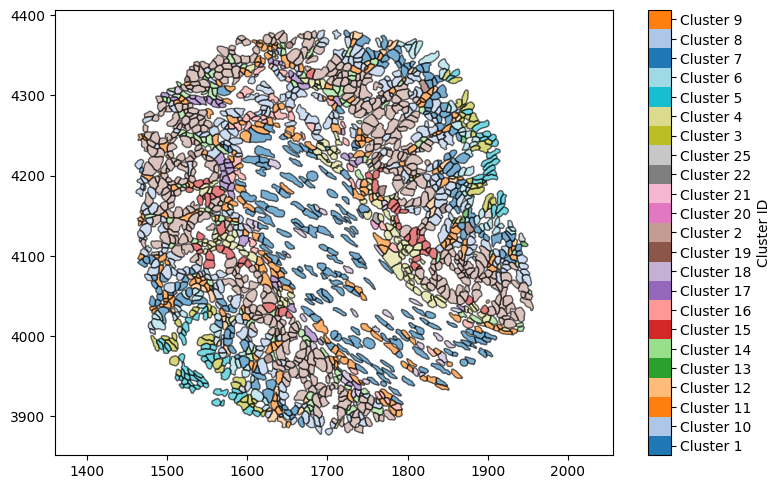

In [4]:
# Load the example domain data
domain = ms.datasets.load_example_domain('Xenium-Healthy-Colon')

# Query to get the cell boundaries
cell_boundaries = ms.query.query(domain, 
        ('collection', ), 'is', 'Cell boundaries')

# Plot the cell boundaries
plt.figure(figsize=(8, 5))
ms.visualise.visualise(domain, ax = plt.gca(),
    objects_to_plot = cell_boundaries, 
    color_by = 'Cluster ID')

Varies statistical tools will have difficulty with shapes and work with points e.g. pair correlation function and persistent homology. MuSpan provides the `domain.convert_objects()` function to convert between types and save as a new collection. It will accept a list of Sample IDs or a query to select the objects to be converted.

In [7]:
# Convert cell boundaries to centroids
domain.convert_objects(
    population = ('Collection', 'Cell boundaries'),
    object_type = 'point',
    conversion_method = 'centroids',
    collection_name = 'Cell centres',
    inherit_collections = False
)
print(domain)

Domain name: Xenium-Healthy-Colon
Number of objects: 79730
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centres']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript', 'Transcript ID'] 
Networks: [] 
Distance matrices: []


(<Figure size 800x500 with 2 Axes>, <Axes: >)

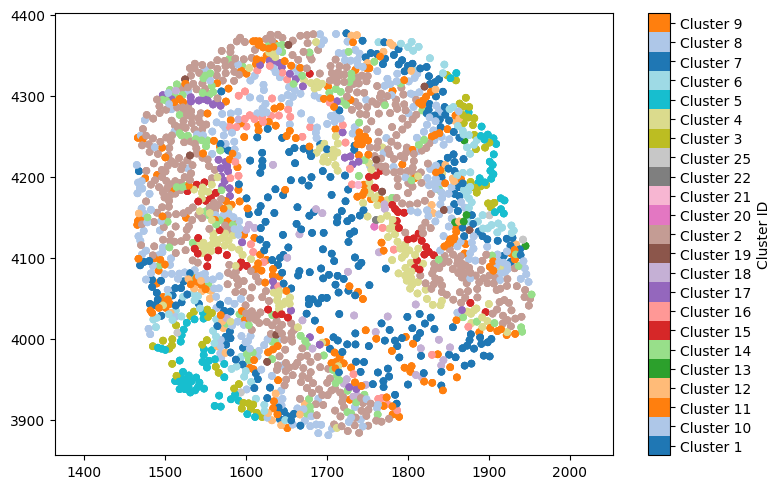

In [10]:

# Plot the cell centres with colour base on 'Cluster ID'
plt.figure(figsize=(8, 5))
ms.visualise.visualise(
    domain,
    objects_to_plot=('collection', 'Cell centres'),
    color_by='Cluster ID',
    ax=plt.gca()
)

(<Figure size 1000x600 with 2 Axes>, <Axes: >)

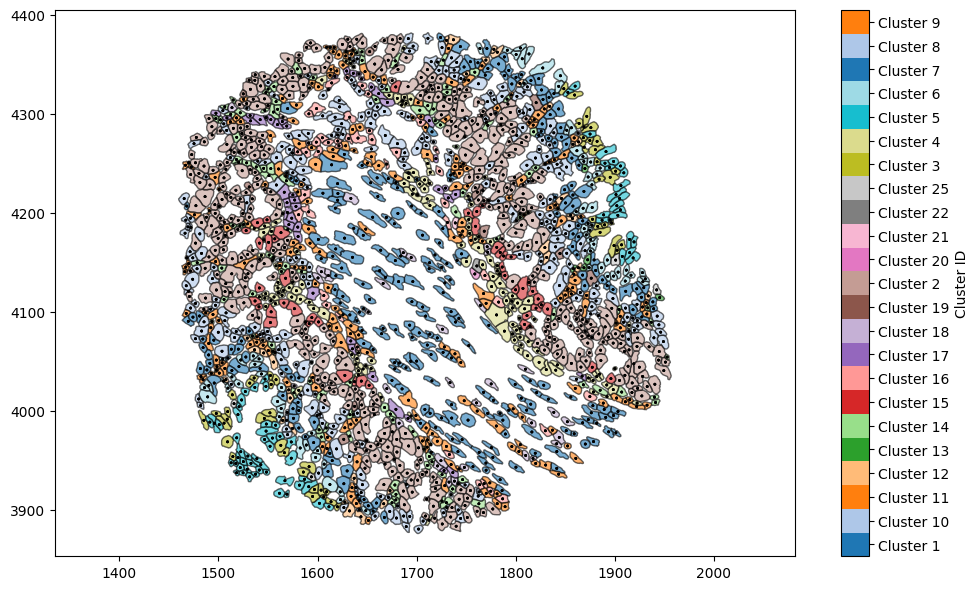

In [11]:
# Create a new figure for the combined plot
plt.figure(figsize=(10, 6))

# Plot the cell boundaries with color based on 'Cluster ID'
ms.visualise.visualise(
    domain,
    objects_to_plot=cell_boundaries,
    color_by='Cluster ID',
    ax=plt.gca()
)

# Overlay the cell centres with a constant color (black) and smaller marker size
ms.visualise.visualise(
    domain,
    objects_to_plot=('collection', 'Cell centres'),
    color_by=('Constant', 'k'),
    ax=plt.gca(),
    marker_size=1,
    add_cbar=False
)

## Decomposing a shape to its vertices

